In [ ]:
import pandas as pd
import numpy as np
from statsmodels.tsa.stattools import adfuller
import statsmodels.api as sm
import matplotlib.pyplot as plt

In [ ]:
# Load the document assuming it's a CSV file
file_path = "TOTF_book_03_04_2017.csv"  # Adjust the file extension if necessary
data = pd.read_csv(file_path)

In [3]:
file_path2 = "TOTF_trade_2014_2017.csv"  # Adjust the file extension if necessary
data2 = pd.read_csv(file_path2)

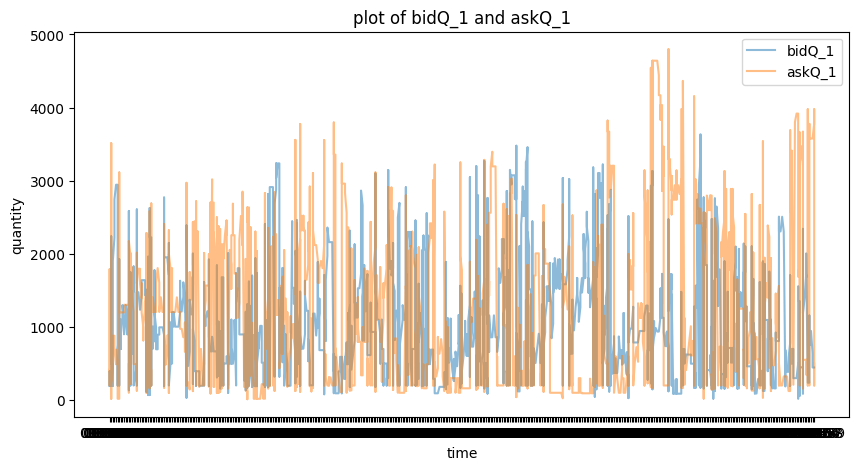

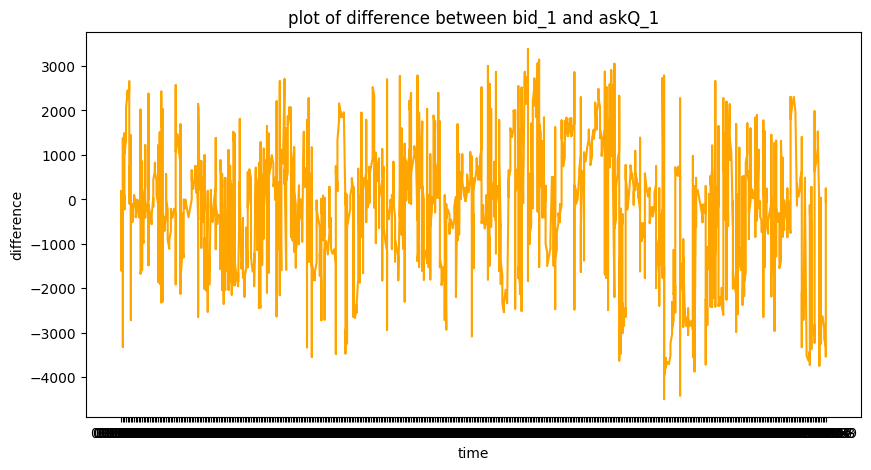

In [4]:
data_day = data[data['date'] == '2017-03-13']
data_HF = data_day[data_day['time'].str.startswith('09:3')]
# Remove rows where bidQ_1 and askQ_1 are the same as the previous row
data_HF = data_HF[(data_HF['bidQ_1'] != data_HF['bidQ_1'].shift(1)) | (data_HF['askQ_1'] != data_HF['askQ_1'].shift(1))]
bidQ_1 = data_HF['bidQ_1'].values
askQ_1 = data_HF['askQ_1'].values
bid_1 = data_HF['bid_1'].values
ask_1 = data_HF['ask_1'].values
difference = (bidQ_1 - askQ_1) 
difference_diff = np.diff(difference)
Time = data_HF['time'].values

plt.figure(figsize=(10, 5))
plt.plot(Time, bidQ_1, alpha=0.5, label='bidQ_1')
plt.plot(Time, askQ_1, alpha=0.5, label='askQ_1')

plt.title('plot of bidQ_1 and askQ_1')
plt.xlabel('time')
plt.ylabel('quantity')
plt.legend()
plt.show()


plt.figure(figsize=(10, 5))
plt.plot(Time, difference, label='moy', color='orange')
plt.title('plot of difference between bid_1 and askQ_1')
plt.xlabel('time')
plt.ylabel('difference')
plt.show()


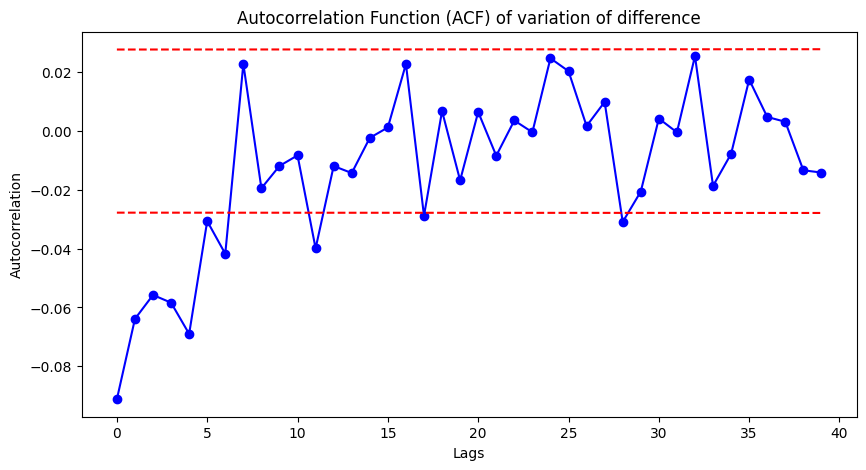

In [5]:
nlags = 40
diff_acf = sm.tsa.acf(difference_diff, nlags=nlags)
N = np.ones(nlags+1)*len(difference) - np.arange(0, nlags+1, 1)

erreur = 2/np.sqrt(N)
plt.figure(figsize=(10, 5))
plt.plot(diff_acf[1:], marker='o', linestyle='-', color='blue')
plt.plot(erreur[1:], linestyle='--', color='red', label='Confidence Interval')
plt.plot(-erreur[1:], linestyle='--', color='red')
plt.title('Autocorrelation Function (ACF) of variation of difference')
plt.xlabel('Lags')

plt.ylabel('Autocorrelation')
plt.show()

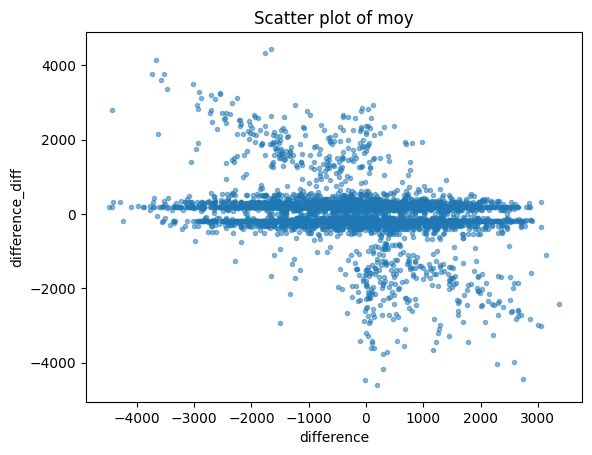

In [6]:
plt.plot(difference[:-1],difference_diff[:], '.', alpha=0.5)
plt.title('Scatter plot of moy')
plt.xlabel('difference')
plt.ylabel('difference_diff')
plt.show()

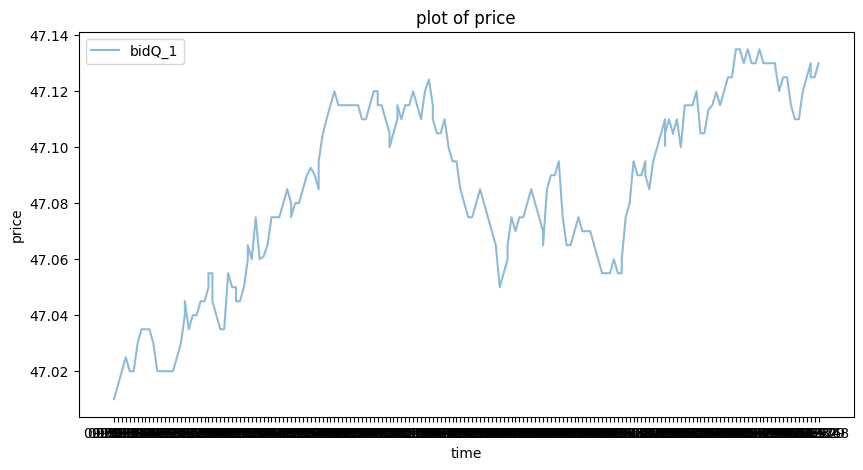

In [7]:
data_day2 = data2[data2['date'] == '2017-03-13']
data_HF2 = data_day2[data_day2['time'].str.startswith('09:')]

plt.figure(figsize=(10, 5))
plt.plot(data_HF2['time'], data_HF2['trade.price'], alpha=0.5, label='bidQ_1')
plt.title('plot of price')
plt.xlabel('time')
plt.ylabel('price')
plt.legend()
plt.show()
